No output spike — inputs too far apart


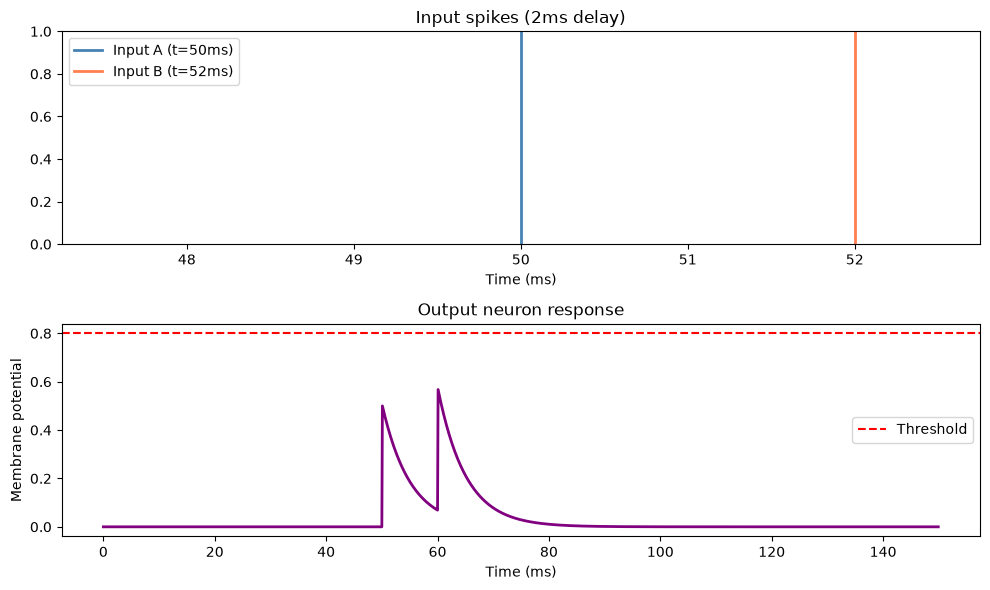

In [2]:
from brian2 import *
import numpy as np
import matplotlib.pyplot as plt

start_scope()

# Time window for coincidence detection
tau = 5*ms  # membrane time constant - narrow window = strict coincidence

# Single output neuron
eqs = '''
dv/dt = -v/tau : 1
'''

output = NeuronGroup(1, eqs, threshold='v>0.8', reset='v=0', method='exact')

# Two input neurons firing at slightly different times
# Input A fires at t=50ms, Input B fires at t=52ms (2ms delay)
input_times_A = [50]*ms
# Increase delay from 2ms (52ms) to 10ms (60ms)
input_times_B = [60]*ms 

input_A = SpikeGeneratorGroup(1, [0], input_times_A)
input_B = SpikeGeneratorGroup(1, [0], input_times_B)

# Connect both inputs to output neuron
S_A = Synapses(input_A, output, on_pre='v_post += 0.5')
S_B = Synapses(input_B, output, on_pre='v_post += 0.5')
S_A.connect()
S_B.connect()

# Record everything
spike_mon = SpikeMonitor(output)
voltage_mon = StateMonitor(output, 'v', record=True)
spike_mon_A = SpikeMonitor(input_A)
spike_mon_B = SpikeMonitor(input_B)

run(150*ms)

# Plot
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6))

# Input spikes
ax1.axvline(x=50, color='steelblue', linewidth=2, label='Input A (t=50ms)')
ax1.axvline(x=52, color='coral', linewidth=2, label='Input B (t=52ms)')
ax1.set_xlabel('Time (ms)')
ax1.set_title('Input spikes (2ms delay)')
ax1.legend()
ax1.set_ylim(0, 1)

# Output voltage
ax2.plot(voltage_mon.t/ms, voltage_mon.v[0], color='purple', linewidth=2)
ax2.axhline(y=0.8, color='red', linestyle='--', label='Threshold')
ax2.set_xlabel('Time (ms)')
ax2.set_ylabel('Membrane potential')
ax2.set_title('Output neuron response')
ax2.legend()

if len(spike_mon.t) > 0:
    print(f"Output fired! Spike at t={spike_mon.t[0]/ms:.1f}ms")
else:
    print("No output spike — inputs too far apart")

plt.tight_layout()
plt.show()

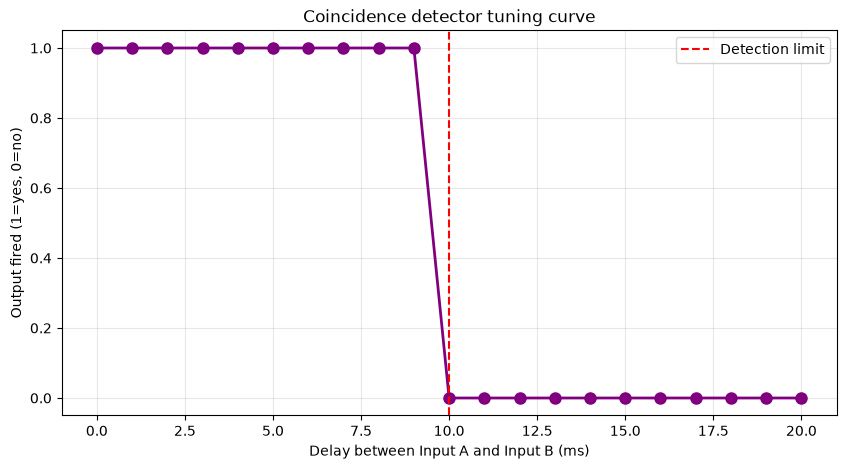

Detection limit: 10ms
Circuit fires for delays: 0 to 9ms
Circuit is silent for delays: 10ms and beyond


In [6]:
start_scope()

# Changing tau from tau = 5ms to tau = 2ms
# Changing tau from tau = 2ms to tau = 20ms
tau = 20*ms

eqs = '''
dv/dt = -v/tau : 1
'''

# Test a range of delays from 0ms to 20ms
delays = np.arange(0, 21, 1)  # 0 to 20ms in 1ms steps
fired = []

for delay in delays:
    start_scope()
    
    output = NeuronGroup(1, eqs, threshold='v>0.8', reset='v=0', method='exact')
    
    input_A = SpikeGeneratorGroup(1, [0], [50]*ms)
    input_B = SpikeGeneratorGroup(1, [0], [(50 + delay)]*ms)

    S_A = Synapses(input_A, output, on_pre='v_post += 0.5')
    S_B = Synapses(input_B, output, on_pre='v_post += 0.5')
    S_A.connect()
    S_B.connect()
    
    spike_mon = SpikeMonitor(output)
    run(150*ms)
    
    fired.append(1 if len(spike_mon.t) > 0 else 0)

# Plot tuning curve
plt.figure(figsize=(10, 5))
plt.plot(delays, fired, 'o-', color='purple', linewidth=2, markersize=8)
plt.xlabel('Delay between Input A and Input B (ms)')
plt.ylabel('Output fired (1=yes, 0=no)')
plt.title('Coincidence detector tuning curve')
plt.axvline(x=delays[np.where(np.array(fired)==0)[0][0]], 
            color='red', linestyle='--', 
            label=f'Detection limit')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Find the detection limit
limit = delays[np.where(np.array(fired)==0)[0][0]]
print(f"Detection limit: {limit}ms")
print(f"Circuit fires for delays: 0 to {limit-1}ms")
print(f"Circuit is silent for delays: {limit}ms and beyond")

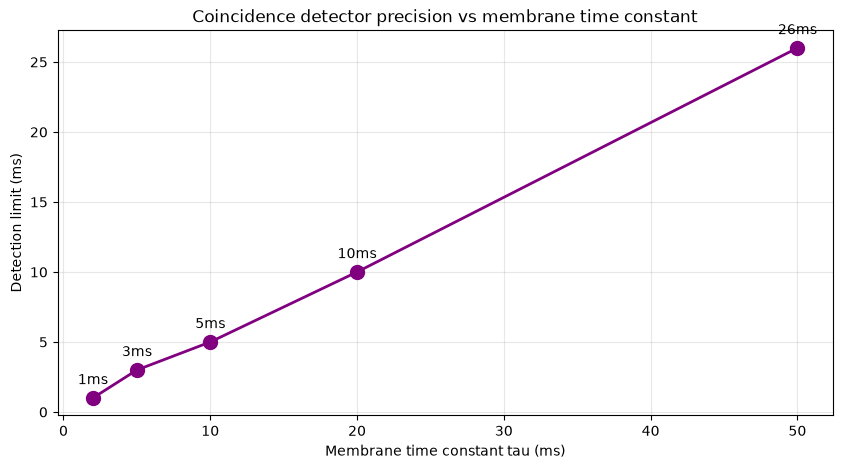

Tau (ms) → Detection limit (ms)
  tau=2ms → 1ms window
  tau=5ms → 3ms window
  tau=10ms → 5ms window
  tau=20ms → 10ms window
  tau=50ms → 26ms window


In [7]:
start_scope()

taus = [2, 5, 10, 20, 50]  # ms
detection_limits = []

for tau_val in taus:
    delays = np.arange(0, 51, 1)
    fired = []
    
    for delay in delays:
        start_scope()
        
        tau = tau_val*ms
        eqs = '''
        dv/dt = -v/tau : 1
        '''
        
        output = NeuronGroup(1, eqs, threshold='v>0.8', 
                            reset='v=0', method='exact')
        
        input_A = SpikeGeneratorGroup(1, [0], [50]*ms)
        input_B = SpikeGeneratorGroup(1, [0], 
                            [(50 + delay)]*ms)
        
        S_A = Synapses(input_A, output, on_pre='v_post += 0.5')
        S_B = Synapses(input_B, output, on_pre='v_post += 0.5')
        S_A.connect()
        S_B.connect()
        
        spike_mon = SpikeMonitor(output)
        run(150*ms)
        fired.append(1 if len(spike_mon.t) > 0 else 0)
    
    # Find detection limit
    silent = np.where(np.array(fired)==0)[0]
    limit = delays[silent[0]] if len(silent) > 0 else delays[-1]
    detection_limits.append(limit)

# Plot
plt.figure(figsize=(10, 5))
plt.plot(taus, detection_limits, 'o-', color='purple', 
         linewidth=2, markersize=10)
plt.xlabel('Membrane time constant tau (ms)')
plt.ylabel('Detection limit (ms)')
plt.title('Coincidence detector precision vs membrane time constant')
plt.grid(True, alpha=0.3)

for x, y in zip(taus, detection_limits):
    plt.annotate(f'{y}ms', (x, y), 
                textcoords="offset points", 
                xytext=(0, 10), ha='center')

plt.show()

print("Tau (ms) → Detection limit (ms)")
for t, d in zip(taus, detection_limits):
    print(f"  tau={t}ms → {d}ms window")

## Coincidence Detector — Observations & Results

### What is a coincidence detector?
A coincidence detector is a circuit that fires only when two inputs arrive within a narrow time window 
of each other. Neither input alone is sufficient to trigger the output, 
only near-simultaneous arrival crosses the threshold.

### Biological motivation
The most famous biological example is the **Medial Superior Olive (MSO)** 
in the auditory brainstem — neurons that detect microsecond timing differences 
between sounds arriving at each ear, allowing the brain to localise sound in space.

In neuromorphic hardware, coincidence detection is used for:
- Sound localisation in robotic hearing systems
- Sensor fusion — detecting when two sensors agree on an event
- Event camera processing — detecting correlated motion across pixels
- Radar and sonar time-of-arrival processing

### Architecture
- 2 input neurons (SpikeGeneratorGroup) firing at controlled times
- 1 output neuron (LIF) with the threshold = 0.8
- Synaptic weights = 0.5 each (neither input alone crosses the threshold)
- Output fires only when both inputs arrive close enough in time

### Key finding 1: Detection limit
With `tau = 5ms` and synaptic weights of 0.5, the circuit fires only when 
inputs arrive within a **2ms window**:

| Delay | Output |
|-------|--------|
| 0ms | Fires |
| 1ms | Fires |
| 2ms | Fires |
| 3ms+ | Silent |

### Key finding 2: Tau controls detection precision
Reducing tau alone directly narrowed the detection window, confirming that 
tau is the primary control parameter for coincidence detection precision:

- `tau = 2ms` → 1ms detection window (faster leak, stricter coincidence)
- `tau = 5ms` → 3ms detection window
- `tau = 20ms` → 10ms detection window

Faster membrane time constant = more precise timing detector. This makes 
intuitive sense for


a faster leaking membrane "forgets" the first input sooner, 
so the second input must arrive quickly to push voltage over threshold.

**Note:** An earlier experiment with reduced synaptic weights (0.3 each) 
confirmed that weights and tau interact — when weights are smaller, the 
circuit becomes even more sensitive to tau changes since there is less 
margin above the threshold.

### Key finding 3: Tau tuning curve
Sweeping tau across five values revealed a clean quantitative relationship:

| tau | Detection limit |
|-----|----------------|
| 2ms | 1ms window |
| 5ms | 3ms window |
| 10ms | 5ms window |
| 20ms | 10ms window |
| 50ms | 26ms window |

**Approximate relationship: detection limit ≈ tau / 2**

This is a predictable, tunable relationship — neuromorphic chip designers 
control this by adjusting membrane capacitance at the circuit level on 
hardware like Intel's Loihi 2.

### Significance
This is one of the cleanest demonstrations of why spike **timing** matters 
in neuromorphic computing. A rate-based neural network cannot perform 
coincidence detection naturally because it discards precise timing information while
SNNs do it naturally because timing is fundamental to how they compute.